# VLM Vehicle Attribute Comparison

Compares accuracy across VLM runs (different prompts, and later, fine-tuned vs
zero-shot) on make / body_type / colour, using the per-image CSVs produced by
`scripts/eval_vlm_zero_shot.py`.

**To add a new run** (e.g. a fine-tuned model's results), add one entry to
`RUNS` in the next code cell — nothing else needs to change.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm

pd.set_option("display.width", 120)
RESULTS_DIR = Path("../../results")

## 1. Configure runs

`label` is what shows up in charts/tables. `path` is the CSV from the eval
script. `attrs` lists which attributes that CSV was scored on (a colour-only
surveillance run only has `colour`, etc.).

In [2]:
RUNS = [
    {
        "label": "Zero-shot (raw prompt)",
        "path": RESULTS_DIR / "vlm_eval_compcars_classification_raw.csv",
        "attrs": ["make", "body_type"],
    },
    {
        "label": "Zero-shot (constrained prompt)",
        "path": RESULTS_DIR / "vlm_eval_compcars_classification_constrained.csv",
        "attrs": ["make", "body_type"],
    },
    {
        "label": "Zero-shot (raw prompt) — colour",
        "path": RESULTS_DIR / "vlm_eval_compcars_surveillance_classification_raw.csv",
        "attrs": ["colour"],
    },
    {
        "label": "Zero-shot (constrained prompt) — colour",
        "path": RESULTS_DIR / "vlm_eval_compcars_surveillance_classification_constrained.csv",
        "attrs": ["colour"],
    },
    
]

## 2. Load and score

Wilson score intervals are used for the 95% CI on accuracy — more reliable
than the normal approximation at n≈100 and near the edges (close to 0% or
100%).

In [3]:
def wilson_ci(successes: int, n: int, z: float = 1.96):
    """Wilson score interval for a binomial proportion. Returns (low, high)."""
    if n == 0:
        return (np.nan, np.nan)
    p = successes / n
    denom = 1 + z**2 / n
    centre = p + z**2 / (2 * n)
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n)
    return ((centre - margin) / denom, (centre + margin) / denom)


def load_run(run: dict) -> pd.DataFrame:
    df = pd.read_csv(run["path"])
    if "error" in df.columns:
        df["error"] = df["error"].fillna("")  # pandas reads "" back as NaN
    n_total = len(df)
    n_failed = (df["error"].astype(str) != "").sum() if "error" in df else 0
    rows = []
    for attr in run["attrs"]:
        ok_col, gt_col = f"{attr}_ok", f"{attr}_gt"
        if ok_col not in df.columns:
            print(f"  [skip] {run['label']}: no {ok_col} column")
            continue
        scored = df[df[gt_col].notna()] if gt_col in df.columns else df
        scored = scored[scored["error"].astype(str) == ""] if "error" in scored else scored
        n = len(scored)
        successes = int(scored[ok_col].astype(bool).sum())
        acc = successes / n if n else np.nan
        lo, hi = wilson_ci(successes, n)
        rows.append({
            "run": run["label"], "attribute": attr, "n": n,
            "accuracy": acc, "ci_low": lo, "ci_high": hi,
            "n_total_images": n_total, "n_failed": n_failed,
        })
    tokens_in = df["prompt_tokens"].sum() if "prompt_tokens" in df else 0
    tokens_out = df["output_tokens"].sum() if "output_tokens" in df else 0
    return pd.DataFrame(rows), tokens_in, tokens_out


summary_rows, cost_rows = [], []
# gemini-3.1-flash-lite pricing (USD per token) — update if pricing or model changes
PRICE_IN, PRICE_OUT = 0.25 / 1_000_000, 1.50 / 1_000_000

for run in RUNS:
    if not run["path"].exists():
        print(f"  [missing] {run['path']} — skipping '{run['label']}'")
        continue
    scored_df, tin, tout = load_run(run)
    summary_rows.append(scored_df)
    cost_rows.append({
        "run": run["label"], "tokens_in": int(tin), "tokens_out": int(tout),
        "est_cost_usd": tin * PRICE_IN + tout * PRICE_OUT,
    })

summary = pd.concat(summary_rows, ignore_index=True) if summary_rows else pd.DataFrame()
costs = pd.DataFrame(cost_rows)
summary

,run,attribute,n,accuracy,ci_low,ci_high,n_total_images,n_failed
0,Zero-shot (raw prompt),make,99,0.868687,0.788201,0.921628,100,1
1,Zero-shot (raw prompt),body_type,98,0.816327,0.728248,0.880540,100,1
2,Zero-shot (constrained prompt),make,100,0.870000,0.790195,0.922429,100,0
3,Zero-shot (constrained prompt),body_type,99,0.858586,0.776526,0.913856,100,0
4,Zero-shot (raw prompt) — colour,colour,100,0.910000,0.837736,0.951928,100,0
5,Zero-shot (constrained prompt) — colour,colour,100,0.850000,0.767163,0.906941,100,0


## 3. Accuracy by run, with 95% CI

In [4]:
display_tbl = summary.copy()
display_tbl["accuracy"] = (display_tbl["accuracy"] * 100).round(1)
display_tbl["ci_low"] = (display_tbl["ci_low"] * 100).round(1)
display_tbl["ci_high"] = (display_tbl["ci_high"] * 100).round(1)
display_tbl[["run", "attribute", "n", "accuracy", "ci_low", "ci_high", "n_failed"]]

,run,attribute,n,accuracy,ci_low,ci_high,n_failed
0,Zero-shot (raw prompt),make,99,86.9,78.8,92.2,1
1,Zero-shot (raw prompt),body_type,98,81.6,72.8,88.1,1
2,Zero-shot (constrained prompt),make,100,87.0,79.0,92.2,0
3,Zero-shot (constrained prompt),body_type,99,85.9,77.7,91.4,0
4,Zero-shot (raw prompt) — colour,colour,100,91.0,83.8,95.2,0
5,Zero-shot (constrained prompt) — colour,colour,100,85.0,76.7,90.7,0


## 4. Grouped bar chart

One panel per attribute, one bar per run, with 95% CI error bars. Non-overlapping
error bars are a reasonable (not rigorous) sign the difference is real.

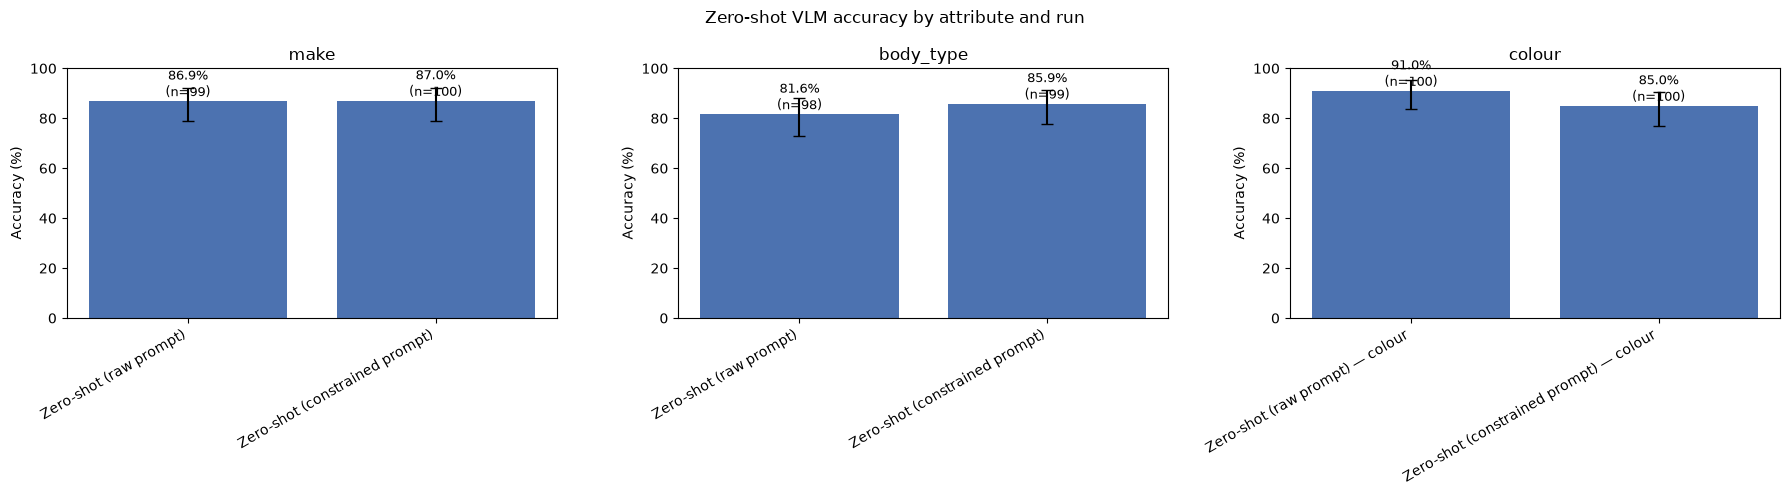

In [5]:
attrs_present = summary["attribute"].unique().tolist()
fig, axes = plt.subplots(1, len(attrs_present), figsize=(6 * len(attrs_present), 5), squeeze=False)
axes = axes[0]

for ax, attr in zip(axes, attrs_present):
    sub = summary[summary["attribute"] == attr]
    x = np.arange(len(sub))
    acc = sub["accuracy"].to_numpy() * 100
    err_low = acc - sub["ci_low"].to_numpy() * 100
    err_high = sub["ci_high"].to_numpy() * 100 - acc
    ax.bar(x, acc, yerr=[err_low, err_high], capsize=4, color="#4C72B0")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["run"], rotation=30, ha="right")
    ax.set_ylim(0, 100)
    ax.set_ylabel("Accuracy (%)")
    ax.set_title(attr)
    for xi, a, n in zip(x, acc, sub["n"]):
        ax.text(xi, a + 2, f"{a:.1f}%\n(n={n})", ha="center", fontsize=9)

fig.suptitle("Zero-shot VLM accuracy by attribute and run")
fig.tight_layout()
plt.show()

## 5. Top confusions per run

Shows what the model gets wrong, not just how often — the more useful view
for deciding what fine-tuning needs to fix.

In [10]:
def top_mismatches(run: dict, attr: str, k: int = 8) -> pd.DataFrame:
    df = pd.read_csv(run["path"])
    if "error" in df.columns:
        df["error"] = df["error"].fillna("")  # pandas reads "" back as NaN
    gt_col, pred_col, ok_col = f"{attr}_gt", f"{attr}_pred", f"{attr}_ok"
    if ok_col not in df.columns:
        return pd.DataFrame()
    wrong = df[(df["error"].astype(str) == "") & (~df[ok_col].astype(bool)) & df[gt_col].notna()]
    if wrong.empty:
        return pd.DataFrame()
    return (
        wrong.groupby([gt_col, pred_col], dropna=False)
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(k)
    )


for run in RUNS:
    if not run["path"].exists():
        continue
    for attr in run["attrs"]:
        mism = top_mismatches(run, attr)
        if mism.empty:
            continue
        print(f"--- {run['label']} — {attr} ---")
        display(mism)

--- Zero-shot (raw prompt) — make ---


,make_gt,make_pred,count
0,Baojun,Chevrolet,1
1,Besturn,FAW,1
2,Changan,Proton,1
3,Chrey,Riich,1
4,DS,Citroën,1
5,Dongfengfengshen,Dongfeng,1
6,GreatWall,GAC Trumpchi,1
7,Haval,Great Wall,1


--- Zero-shot (raw prompt) — body_type ---


,body_type_gt,body_type_pred,count
7,sedan,coupe,4
3,fastback,hatchback,3
9,sports,coupe,3
2,SUV,pickup truck,1
1,SUV,hatchback,1
0,MPV,hatchback,1
4,fastback,sedan,1
6,minibus,van,1


--- Zero-shot (constrained prompt) — make ---


...

,body_type_gt,body_type_pred,count
6,sedan,sports,4
0,SUV,crossover,2
4,hatchback,crossover,2
2,fastback,hatchback,1
1,SUV,pickup,1
3,fastback,sedan,1
5,sedan,hatchback,1
7,sports,fastback,1


--- Zero-shot (raw prompt) — colour — colour ---


,colour_gt,colour_pred,count
1,champagne,brown,2
3,silver,black,2
0,blue,grey,1
2,red,purple,1
4,silver,blue,1
5,silver,brown,1
6,yellow,orange,1


--- Zero-shot (constrained prompt) — colour — colour ---


,colour_gt,colour_pred,count
8,silver,brown,3
5,red,purple,2
6,silver,black,2
4,red,brown,2
1,blue,silver,1
0,blue,black,1
2,brown,black,1
3,champagne,brown,1


## 6. Tokens and estimated cost per run

In [7]:
costs_display = costs.copy()
costs_display["est_cost_usd"] = costs_display["est_cost_usd"].round(4)
costs_display

,run,tokens_in,tokens_out,est_cost_usd
0,Zero-shot (raw prompt),114642,2901,0.0330
1,Zero-shot (constrained prompt),120700,2913,0.0345
2,Zero-shot (raw prompt) — colour,116338,2878,0.0334
3,Zero-shot (constrained prompt) — colour,121238,2874,0.0346


In [11]:
display(top_mismatches(RUNS[3], "colour"))

,colour_gt,colour_pred,count
8,silver,brown,3
5,red,purple,2
6,silver,black,2
4,red,brown,2
1,blue,silver,1
0,blue,black,1
2,brown,black,1
3,champagne,brown,1


In [12]:
df = pd.read_csv(RUNS[3]["path"])
df[(df["colour_gt"] == "silver") & (df["colour_pred"] == "brown")][["image"]]

,image
16,data\raw\compcars\sv_data\image\170\c01df81ba6...
20,data\raw\compcars\sv_data\image\256\867382033e...
93,data\raw\compcars\sv_data\image\102\127e1ebfb6...


In [1]:
from google import genai
client = genai.Client(vertexai=True, project="auth-2b5a7", location="us-central1")
job = client.tunings.get(name="projects/972693698520/locations/us-central1/tuningJobs/6263311783683948544")
spec = job.supervised_tuning_spec
print("hyperparameters:", spec.hyper_parameters)
print("training dataset stats:", job.tuning_data_stats)

hyperparameters: adapter_size=<AdapterSize.ADAPTER_SIZE_TWO: 'ADAPTER_SIZE_TWO'> batch_size=None epoch_count=3 learning_rate=None learning_rate_multiplier=1.0
training dataset stats: distillation_data_stats=None preference_optimization_data_stats=None supervised_tuning_data_stats=SupervisedTuningDataStats(
  total_billable_token_count=587983,
  tuning_dataset_example_count=480,
  user_dataset_examples=[
    Content(
      parts=[
        Part(
          text="""<media0>Look at this vehicle image and identify:
- make (manufacturer)
- model
- body type: must be exactly one of sedan, SUV, hatchback, sports, MPV, fastback, estate, hardtop convertible, minibus, convertible, pickup, crossover

Respond ONLY in this exact JSON format:
{"make": "...", "model": "...", "body_type": "..."}
"""
        ),
      ],
      role='user'
    ),
    Content(
      parts=[
        Part(
          text='{"make": "Renault", "model": "Koleos", "body_type": "SUV"}'
        ),
      ],
      role='model'
    ),